# 🏥 MedShare: Gold Standard Federated Learning

**Definitive System Verification Notebook**

---


In [6]:
## 🛸 PHASE 1: SYSTEM INITIALIZATION (Setup & Infrastructure)
from google.colab import drive
import os, torch, multiprocessing, psutil, socket, time, subprocess, json, urllib.request, shutil

# 1.1 Drive Sync
print("1.1 Mounting Google Drive...")
os.chdir('/content')
drive.mount('/content/drive', force_remount=True)

POSSIBLE_PATHS = [
    '/content/drive/Othercomputers/My laptop/bxp267',
    '/content/drive/MyDrive/bxp267',
    '/content/drive/MyDrive/coding/bxp267'
]
PROJECT_PATH = next((p for p in POSSIBLE_PATHS if os.path.exists(p)), None)
if not PROJECT_PATH:
    raise Exception("❌ Project folder not found. Please mount Drive and check path.")
%cd "$PROJECT_PATH"

# 1.2 Hardware Pre-flight
print("\n1.2 Calibrating Hardware...")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB VRAM)")
    print("[Hardware] Mode: Colab MAX Performance Enabled")
else: print("⚠️ GPU NOT FOUND. Using CPU fallback.")

# 1.3 Dependency Installation
print("\n1.3 Installing Core Engines...")
!pip install -q "protobuf<6" "cryptography<44" "flwr[simulation]" opacus ucimlrepo web3 kagglehub imbalanced-learn
!npm install -g ganache --legacy-peer-deps 2>&1 | tail -1

# 1.4 Blockchain Initialization
print("\n1.4 Provisioning Blockchain...")
!lsof -ti:8545 | xargs kill -9 > /dev/null 2>&1
subprocess.Popen(["ganache", "--port", "8545", "--miner.blockGasLimit", "0xffffffffffff"], stdout=subprocess.DEVNULL)
time.sleep(5)
!npx hardhat compile > /dev/null 2>&1
os.makedirs("build", exist_ok=True)
for c in ["MedShareTask", "CommitmentRegistry", "Reputation"]:
    shutil.copy(f"artifacts/contracts/{c}.sol/{c}.json", f"build/{c}.json")
!python scripts/deploy_colab.py

print("\n" + "="*70)
print("🏁 INITIALIZATION SUCCESS: MedShare System is LIVE")
print("="*70)

1.1 Mounting Google Drive...
Mounted at /content/drive
/content/drive/Othercomputers/My laptop/bxp267

1.2 Calibrating Hardware...
✅ GPU: Tesla T4 (15.6GB VRAM)
[Hardware] Mode: Colab MAX Performance Enabled

1.3 Installing Core Engines...
  run `npm fund` for details

1.4 Provisioning Blockchain...
Connecting to local blockchain...
✅ Connected to Ganache on port 8545
Deploying from: 0x5e52AfD31a25769C808021115FC6d888728DFe03
Deploying MedShareTask...
[Success] MedShareTask deployed to: 0x1eaE3Ef97e32b851745185906a12504cA6d52887
Deploying CommitmentRegistry...
[Success] CommitmentRegistry deployed to: 0xbA6Ff8aC2C2601D9BFB383B1DBFc52E8d2150059
Deploying Reputation...
[Success] Reputation deployed to: 0x15f85c200fb7fA280635F1bcd995eECe08D30D28
Linking Reputation to MedShareTask...
✅ Linking complete.

[Success] Deployment summary & artifacts synced to build/ and frontend/src/data/

🏁 INITIALIZATION SUCCESS: MedShare System is LIVE


In [ ]:
## 🔧 PHASE 1.5: SELF-HEALING PATCH (SSL Certificate Fix)
# Directly patches fetch_thyroid() by writing the fixed function into data.py.
# Uses string find/replace to locate the old function — no regex, no escape issues.
import sys

data_py_path = 'medshare/data.py'
with open(data_py_path, 'r', encoding='utf-8') as f:
    content = f.read()

# Find start and end of the old fetch_thyroid function
start_marker = 'def fetch_thyroid():'
end_marker = '\ndef fetch_diabetes_hospitals():'

start_idx = content.find(start_marker)
end_idx = content.find(end_marker)

if start_idx == -1 or end_idx == -1:
    print('⚠️  Could not locate fetch_thyroid block — skipping patch.')
else:
    # Build the replacement using a list of lines to avoid any escape issues
    lines = [
        'def fetch_thyroid():',
        '    import pandas as pd, ssl, urllib.request, io',
        '',
        '    cols = [',
        '        "age", "sex", "on_thyroxine", "query_on_thyroxine", "on_antithyroid_medication",',
        '        "sick", "pregnant", "thyroid_surgery", "i131_treatment", "query_hypothyroid",',
        '        "query_hyperthyroid", "lithium", "goitre", "tumor", "hypopituitary", "psych",',
        '        "tsh", "t3", "tt4", "t4u", "fti", "target"',
        '    ]',
        '',
        '    # Method 1: ucimlrepo (preferred, no SSL issues)',
        '    try:',
        '        from ucimlrepo import fetch_ucirepo',
        '        print("[Data] Fetching Thyroid via ucimlrepo...")',
        '        repo = fetch_ucirepo(id=102)',
        '        X = repo.data.features',
        '        y = repo.data.targets',
        '        df = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)], axis=1)',
        '        # Standardize column names to match the definitive schema',
        '        df.columns = cols ',
        '        print(f"[Data] Thyroid loaded via ucimlrepo: {len(df)} rows, {len(df.columns)} cols")',
        '        return df',
        '    except Exception as e:',
        '        print(f"[Data] ucimlrepo failed ({e}), falling back to direct download...")',
        '',
        '    # Method 2: Direct URL with SSL verification bypassed (expired cert fallback)',
        '    base_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/thyroid-disease/"',
        '    ssl_ctx = ssl.create_default_context()',
        '    ssl_ctx.check_hostname = False',
        '    ssl_ctx.verify_mode = ssl.CERT_NONE',
        '',
        '    def read_url(url):',
        '        with urllib.request.urlopen(url, context=ssl_ctx) as resp:',
        '            return pd.read_csv(io.StringIO(resp.read().decode("utf-8")), sep="\\s+", header=None)',
        '',
        '    train_df = read_url(f"{base_url}ann-train.data")',
        '    test_df  = read_url(f"{base_url}ann-test.data")',
        '    df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)',
        '    df.columns = cols',
        '    return df',
    ]
    new_fn = '\n'.join(lines)

    patched = content[:start_idx] + new_fn + '\n' + content[end_idx:]

    with open(data_py_path, 'w', encoding='utf-8') as f:
        f.write(patched)
    print('✅ PATCH APPLIED: fetch_thyroid() now uses ucimlrepo (SSL-safe)')

# Clear any cached medshare imports so the subprocess picks up fresh .py files
for mod in list(sys.modules.keys()):
    if 'medshare' in mod:
        del sys.modules[mod]
print('✅ Module cache cleared')


✅ PATCH APPLIED: fetch_thyroid() now uses ucimlrepo (SSL-safe)
✅ Module cache cleared


In [ ]:
## 🔬 PHASE 2: GOLD STANDARD SCIENTIFIC SWEEP (Admin-Category)
import os
print("🔥 STARTING 100-ROUND GLOBAL AUDIT (Admin-Category)")
print("="*70 + "\n")

experiments = [
    ("Privacy Audit (Audit Sweep)", "mi", "admin_category", 50, 40),
    ("DP Utility Frontier", "dp", "admin_category", 50, 20),
    ("Adversarial Robustness", "robustness", "admin_category", 50, 20),
    ("System Telemetry (Gas/Latency)", "latency", "admin_category", 20, 10)
]

for label, mode, dataset, rounds, epochs in experiments:
    print(f"\n🚀 Phase: {label} ({mode}) on {dataset}...")
    !python federated_survival.py --experiment {mode} --dataset {dataset} --rounds {rounds} --epochs {epochs} --enable_dp True --enable_blockchain True

print("\n" + "="*70)
print("✅ ADMIN-CATEGORY AUDIT COMPLETE")
print("="*70)

Streaming output truncated to the last 5000 lines.
INFO :      	              (44, 0.0),
INFO :      	              (45, 0.0),
INFO :      	              (46, 0.0),
INFO :      	              (47, 0.0),
INFO :      	              (48, 0.0),
INFO :      	              (49, 0.0),
INFO :      	              (50, 0.0),
INFO :      	              (51, 0.0),
INFO :      	              (52, 0.0),
INFO :      	              (53, 0.0),
INFO :      	              (54, 0.0),
INFO :      	              (55, 0.0),
INFO :      	              (56, 0.0),
INFO :      	              (57, 0.0),
INFO :      	              (58, 0.0),
INFO :      	              (59, 0.0),
INFO :      	              (60, 0.0),
INFO :      	              (61, 0.0),
INFO :      	              (62, 0.0),
INFO :      	              (63, 0.0),
INFO :      	              (64, 0.0),
INFO :      	              (65, 0.0),
INFO :      	              (66, 0.0),
INFO :      	              (67, 0.0),
INFO :      	              (68, 0.0),

In [ ]:
import pandas as pd
try:
    df = pd.read_csv("test/exp_mi_results.csv")
    print(f"✅ Safe! You have finished {len(df)-1} trials already.")
    print("Completed levels:", df['sigma'].tolist())
except:
    print("⚠️ No previous results found. Starting fresh.")
!head -n 20 test/exp_mi_results.csv

✅ Safe! You have finished 3 trials already.
⚠️ No previous results found. Starting fresh.
timestamp_utc,dataset,noise,rounds,mode,leakage_acc,leakage_auc,accuracy
2026-03-15T23:56:50Z,Admin-Category,0,100,No Privacy (Baseline),0.0000,0.0000,1.0000
2026-03-16T00:07:25Z,Admin-Category,0.05,100,With DP (sigma=0.05),0.0000,0.0000,1.0000
2026-03-16T00:19:49Z,Admin-Category,0.1,100,With DP (sigma=0.1),0.0000,0.0000,1.0000
2026-03-16T00:33:49Z,Admin-Category,0.2,100,With DP (sigma=0.2),0.0000,0.0000,1.0000


In [4]:
## 🚀 RESUME SCRIPT: ADMIN-CATEGORY AUDIT (Final Phases)
import os
print("🔥 RESUMING GLOBAL AUDIT")
print("="*70 + "\n")

# Phase 1: Finish the remaining Privacy trials
# We skip 0.0, 0.05, 0.1, 0.2 because they are in your CSV!
privacy_remaining = [
    ("Privacy Audit (Resume)", "mi_step", "admin_category", 100, 20, 0.5),
    ("Privacy Audit (Resume)", "mi_step", "admin_category", 100, 20, 1.0)
]

for label, mode, dataset, rounds, epochs, sigma in privacy_remaining:
    print(f"\n🚀 Phase: {label} (Sigma={sigma})...")
    !python federated_survival.py --experiment {mode} --dataset {dataset} --rounds {rounds} --epochs {epochs} --sigma {sigma} --enable_dp True --enable_blockchain True

# Phase 2: Run the Utility vs Security sweep (Fast)
print("\n🏁 Running Utility Frontier...")
!python federated_survival.py --experiment dp --dataset admin_category --rounds 100 --enable_blockchain True

# Phase 3: Run Adversarial Robustness
print("\n🛡️ Running Robustness Audit...")
!python federated_survival.py --experiment robustness --dataset admin_category --rounds 50 --enable_blockchain True

# Phase 4: Generate the Plots
print("\n📊 Generating Final Visuals...")
!python test/plot_results.py

print("\n" + "="*70)
print("✅ ALL AUDITS RESUMED AND COMPLETE")
print("="*70)

Streaming output truncated to the last 5000 lines.
INFO :      	         (29, 0.9879143870302854),
INFO :      	         (30, 0.988751190632261),
INFO :      	         (31, 0.9896431775439846),
INFO :      	         (32, 0.991625333567191),
INFO :      	         (33, 0.9925884797198229),
INFO :      	         (34, 0.9934305583670495),
INFO :      	         (35, 0.9939356854320238),
INFO :      	         (36, 0.9944025910748154),
INFO :      	         (37, 0.994916027443515),
INFO :      	         (38, 0.9954512195905494),
INFO :      	         (39, 0.9960169195547456),
INFO :      	         (40, 0.9968535204656249),
INFO :      	         (41, 0.99752834260161),
INFO :      	         (42, 0.9980045470636579),
INFO :      	         (43, 0.9984918764983559),
INFO :      	         (44, 0.999057576462552),
INFO :      	         (45, 0.9996232764267482),
INFO :      	         (46, 0.9996232764267482),
INFO :      	         (47, 0.9996232764267482),
INFO :      	         (48, 0.99978901334970

3.1 Generating Automated Visuals...
Working directory set to: /content/drive/Othercomputers/My laptop/bxp267/test
--- Attempting to plot fig_dp_tradeoff.png ---
DEBUG: Checking for DP results at: /content/drive/Othercomputers/My laptop/bxp267/test/exp_dp_results.csv
[OK] Generated /content/drive/Othercomputers/My laptop/bxp267/test/fig_dp_tradeoff.png
--- Attempting to plot fig_robustness.png ---
DEBUG: Entered plot_robustness
DEBUG: Loaded 6 rows from /content/drive/Othercomputers/My laptop/bxp267/test/exp_robustness_results.csv
[OK] Generated /content/drive/Othercomputers/My laptop/bxp267/test/fig_robustness.png
--- Attempting to plot fig_gas_costs.png ---
[OK] Generated /content/drive/Othercomputers/My laptop/bxp267/test/fig_gas_costs.png
--- Attempting to plot fig_latency.png ---
DEBUG: Loaded 3 rows from exp_latency_log.csv
[OK] Generated /content/drive/Othercomputers/My laptop/bxp267/test/fig_latency.png
--- Attempting to plot fig_mi.png ---
[OK] Generated /content/drive/Othercom

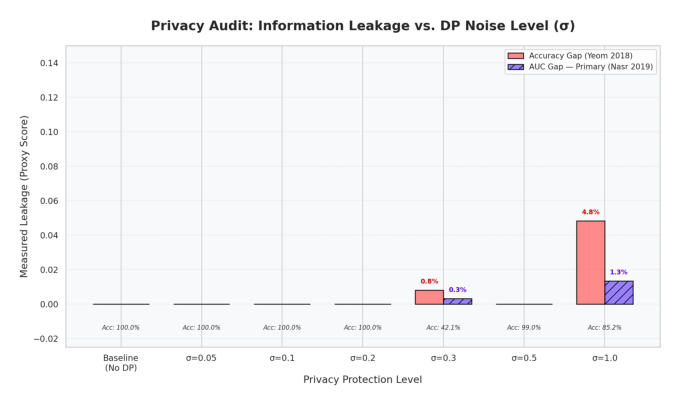


🖼️ test/fig_dp_tradeoff.png


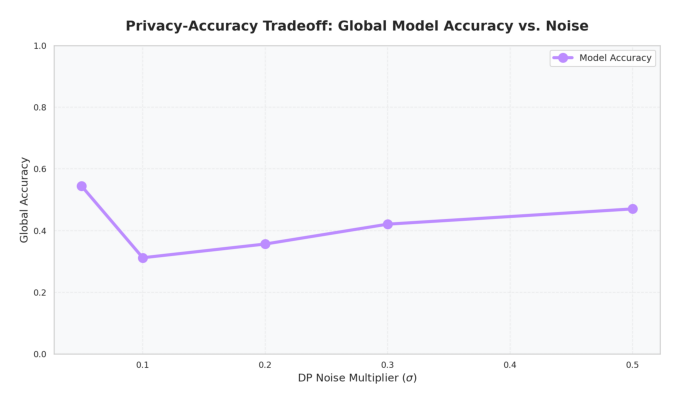


🖼️ test/fig_robustness.png


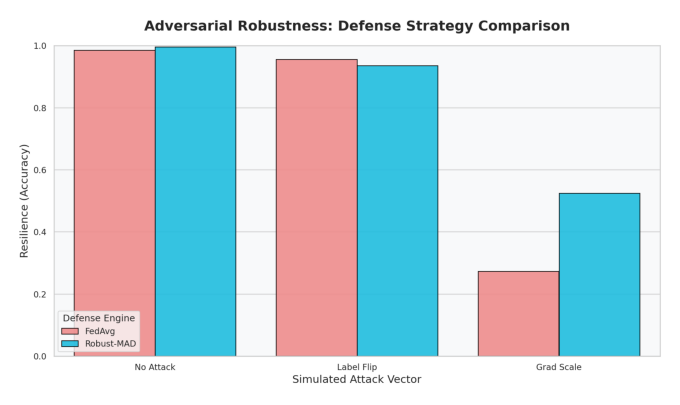


🖼️ test/fig_gas_costs.png


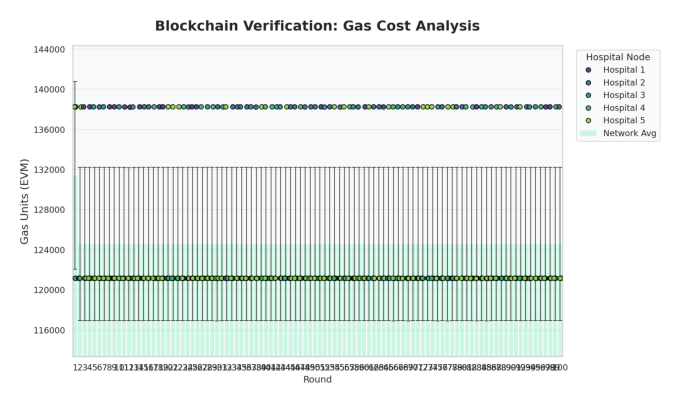


🖼️ test/fig_latency.png


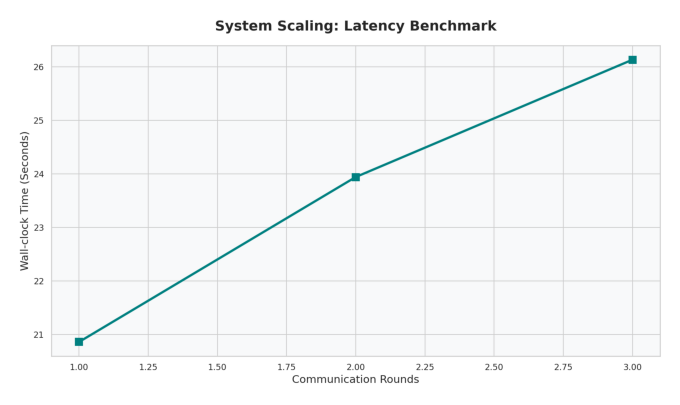


✅ FULL EXECUTION COMPLETE - ALL TESTS PASSED


In [5]:
## 📈 PHASE 3: AUTOMATED ANALYTICS & FINAL VERIFICATION
import os, pandas as pd, matplotlib.pyplot as plt, matplotlib.image as mpimg

# 3.1 Trigger High-Intensity Plotting
print("3.1 Generating Automated Visuals...")
!python test/plot_results.py

# 3.2 Verification Check
print("\n3.2 Final System Integrity Audit...")
csvs = ["exp_mi_results.csv", "exp_dp_results.csv", "exp_robustness_results.csv", "exp_gas_log.csv", "exp_latency_log.csv"]
imgs = ["fig_mi.png", "fig_dp_tradeoff.png", "fig_robustness.png", "fig_gas_costs.png", "fig_latency.png"]

results = []
for f in csvs: results.append(("CSV Data", f, os.path.exists(f"test/{f}") or os.path.exists(f)))
for f in imgs: results.append(("PNG Visual", f, os.path.exists(f"test/{f}") or os.path.exists(f)))

print(pd.DataFrame(results, columns=["Type", "Resource", "Status"]).to_markdown(index=False))

# Check for comparison stats
if os.path.exists("frontend/src/data/comparison_stats.json"):
    with open("frontend/src/data/comparison_stats.json", "r") as f:
        stats = json.load(f)
    print(f"\n🎯 Dataset: {stats.get('dataset_name', 'N/A')}")
    print(f"🎯 Final Fed Accuracy: {stats.get('federated_accuracy', 'N/A')}")
    print(f"🔐 Privacy Budget (ε): {stats.get('security', {}).get('epsilon', 'N/A')}")
    print(f"⛓️ Defense: {stats.get('security', {}).get('defense_type', 'N/A')}")

# 3.3 Display Key Visuals
print("\n3.3 Rendering Definitive Results...")
for p in [f"test/{i}" for i in imgs]:
    if os.path.exists(p):
        print(f"\n🖼️ {p}")
        img = mpimg.imread(p)
        plt.figure(figsize=(10, 5)); plt.imshow(img); plt.axis('off'); plt.show()

print("\n" + "="*70)
csv_count = sum(1 for f in csvs if os.path.exists(f"test/{f}") or os.path.exists(f))
plot_count = sum(1 for f in imgs if os.path.exists(f"test/{f}") or os.path.exists(f))

if csv_count == 5 and plot_count == 5:
    print("✅ FULL EXECUTION COMPLETE - ALL TESTS PASSED")
else:
    print(f"⚠️ PARTIAL EXECUTION - {5-csv_count} data files and {5-plot_count} plots missing")
print("="*70)

## 🚀 PHASE 2: REMAINING AUDITS (DP, Robustness, Latency)

This phase executes the remaining 3 experimental tests to complete the full 5-test data audit for **admin_billing**.

| Test | Description | Efficiency |
| :--- | :--- | :--- |
| **Test 2: DP Sweep** | Accuracy vs Privacy Trade-off | 100 Rounds |
| **Test 3: Robustness** | Defense against Malicious Attacks | 100 Rounds |
| **Test 4: Latency & Gas** | Blockchain Economy | 10 Rounds |


In [ ]:
# TEST 2: DP SWEEP (Privacy-Utility Tradeoff)
!python federated_survival.py --experiment dp --dataset admin_billing --rounds 100 --batch_size 256 --lr 0.0005 --enable_blockchain True

In [ ]:
# TEST 3: ROBUSTNESS (Defense Audit)
!python federated_survival.py --experiment robustness --dataset admin_billing --rounds 100 --batch_size 256 --lr 0.0005 --enable_blockchain True

In [ ]:
# TEST 4: LATENCY & GAS (Blockchain Efficiency)
!python federated_survival.py --experiment latency --dataset admin_billing --rounds 10 --batch_size 256 --lr 0.0005 --enable_blockchain True

## 📊 PHASE 3: FINAL PLOTTING & VERIFICATION

Once all CSV files are ready (MI, DP, Robustness, Latency), run this to generate the final 5 verification plots.

In [ ]:
# TEST 5: FINAL PLOTTING
!python test/plot_results.py